In [57]:
# ========================
# RandomForest & LightGBM
# ========================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (accuracy_score, auc, balanced_accuracy_score, classification_report, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix, precision_recall_curve, make_scorer,
                            RocCurveDisplay, PrecisionRecallDisplay)

import joblib

import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
# ======================
#  DATA LOADING
# ======================
print("Loading data...")
df = pd.read_csv('data.csv')

# Convert target variable
df['OBJ'] = df['OBJ'].map({'NO': 0, 'SI': 1})

# Handle missing values
print("\nHandling missing values...")
df.fillna(df.median(numeric_only=True), inplace=True)

Loading data...

Handling missing values...


In [59]:
# ======================
#  DATA PREPROCESSING
# ======================

# Efficient cross-feature and binarized flag generation using preallocation
cross_features = {}
binarized_flags = {}

for i in range(1, 31):
    for j in range(i + 1, 31):
        cross_features[f'V{i}_x_V{j}'] = df[f'V{i}'] * df[f'V{j}']
    binarized_flags[f'V{i}_gt_mean'] = (df[f'V{i}'] > df[f'V{i}'].mean()).astype(int)

# Concatenate all new features at once
df = pd.concat([df, pd.DataFrame(cross_features), pd.DataFrame(binarized_flags)], axis=1)
df = df.copy()  # Defragment to avoid future warnings

# Target and features
y = df['OBJ']
X = df.drop(columns=['OBJ'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [60]:
# ======================
#  MODEL PIPELINES
# ======================

# Random Forest
pipeline_rf = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# LightGBM pipeline
pipeline_lgbm = ImbPipeline(steps=[
    ('clf', lgb.LGBMClassifier(random_state=42, class_weight='balanced', force_col_wise=True, verbose=-1))
])


In [ ]:
# ======================
#  HYPERPARAMETER GRIDS
# ======================

# Random Forest Params
params_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [5, 10],
    'clf__min_samples_split': [2, 5],
}

# LightGBM Params
params_lgbm = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [5, 10],
    'clf__learning_rate': [0.05, 0.1],
    'clf__min_child_samples': [20, 50],
    'clf__num_leaves': [31, 50]
}

In [62]:
# ======================
#  MODEL TRAINING
# ======================
models = {
    'RandomForest': (pipeline_rf, params_rf),
    'LightGBM': (pipeline_lgbm, params_lgbm)
}

best_models = {}
results = []

print("\n=== MODEL TRAINING ===")
for name, (pipe, params) in models.items():
    print(f"\n{'='*40}")
    print(f"Training {name}...")
    print(f"{'='*40}")

    try:
        # Grid Search with error handling
        gs = GridSearchCV(
            estimator=pipe,
            param_grid=params,
            scoring='f1',
            cv=5,
            n_jobs=-1
        )
        gs.fit(X_train, y_train)

        # Store best model
        best_models[name] = gs.best_estimator_

        # Predictions
        y_pred = gs.predict(X_test)
        y_proba = gs.predict_proba(X_test)[:, 1]

        # Metrics
        metrics = {
            'Model': name,
            'Best Params': gs.best_params_,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_proba)
        }
        results.append(metrics)

        print(f"\n{name} Best Parameters: {gs.best_params_}")
        print(f"Test ROC-AUC: {metrics['ROC-AUC']:.4f}")
        print(f"Test Recall: {metrics['Recall']:.4f}")

    except Exception as e:
        print(f"\nERROR in {name}: {str(e)}")
        print("Trying fallback configuration...")

        # Fallback to default model without grid search
        try:
            pipe.set_params(**{k.split('__')[1]: v for k, v in params[0].items()} if isinstance(params, list) else {k.split('__')[1]: v for k, v in params.items()})
            pipe.fit(X_train, y_train)

            y_pred = pipe.predict(X_test)
            y_proba = pipe.predict_proba(X_test)[:, 1]

            metrics = {
                'Model': name + '_Fallback',
                'Best Params': 'Default',
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, zero_division=0),
                'Recall': recall_score(y_test, y_pred),
                'F1-Score': f1_score(y_test, y_pred),
                'ROC-AUC': roc_auc_score(y_test, y_proba)
            }
            results.append(metrics)

            print(f"Fallback {name} Performance:")
            print(f"Test ROC-AUC: {metrics['ROC-AUC']:.4f}")

        except Exception as fallback_e:
            print(f"Fallback failed: {str(fallback_e)}")
            continue


=== MODEL TRAINING ===

Training RandomForest...

RandomForest Best Parameters: {'clf__max_depth': 5, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Test ROC-AUC: 0.6207
Test Recall: 0.5134

Training LightGBM...

LightGBM Best Parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__min_child_samples': 50, 'clf__n_estimators': 100, 'clf__num_leaves': 31}
Test ROC-AUC: 0.6283
Test Recall: 0.5248



=== MODEL COMPARISON ===
          Model                                        Best Params  Accuracy  \
1      LightGBM  {'clf__learning_rate': 0.05, 'clf__max_depth':...     0.627   
0  RandomForest  {'clf__max_depth': 5, 'clf__min_samples_split'...     0.639   

   Precision    Recall  F1-Score   ROC-AUC  
1   0.356218  0.524809  0.424383  0.628269  
0   0.365489  0.513359  0.426984  0.620709  

Best Model: LightGBM (ROC-AUC: 0.6283)

Optimal threshold: 0.4482 (default=0.5)

Optimized Performance:
Accuracy: 0.5595
Precision: 0.3308
Recall: 0.6660
F1-Score: 0.4421

Classification Report:
              precision    recall  f1-score   support

           0     0.7972    0.6633    0.7241      1476
           1     0.3562    0.5248    0.4244       524

    accuracy                         0.6270      2000
   macro avg     0.5767    0.5940    0.5742      2000
weighted avg     0.6817    0.6270    0.6456      2000



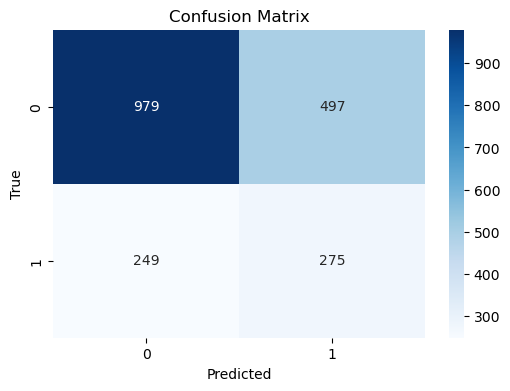

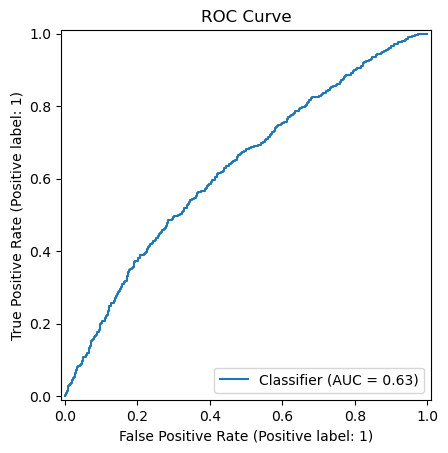

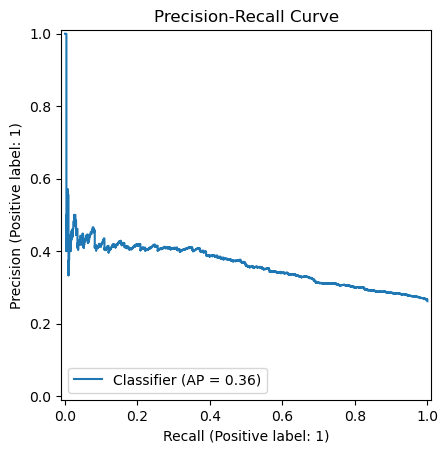

In [66]:
# ======================
#  RESULTS ANALYSIS
# ======================
if results:
    results_df = pd.DataFrame(results)
    print("\n=== MODEL COMPARISON ===")
    print(results_df.sort_values('ROC-AUC', ascending=False))

    # Select best model
    best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
    best_model = best_models[best_model_name]
    print(f"\nBest Model: {best_model_name} (ROC-AUC: {results_df['ROC-AUC'].max():.4f})")

    # Threshold optimization
    y_proba = best_model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)
    best_threshold = thresholds[np.argmax(f1_scores)]

    print(f"\nOptimal threshold: {best_threshold:.4f} (default=0.5)")
    y_pred_opt = (y_proba >= best_threshold).astype(int)

    print("\nOptimized Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_opt, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_opt):.4f}")

    # Predict using the best model from earlier
    final_probs = best_model.predict_proba(X_test)[:, 1]
    final_preds = (final_probs >= 0.5).astype(int)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, final_preds, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, final_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, final_probs)
    plt.title('ROC Curve')
    plt.show()

    # Precision-Recall Curve
    PrecisionRecallDisplay.from_predictions(y_test, final_probs)
    plt.title('Precision-Recall Curve')
    plt.show()
else:
    print("\nNo models trained successfully")


Optimized Performance Reports (using best threshold)

Optimized Classification Report:
              precision    recall  f1-score   support

           0     0.8148    0.5217    0.6361      1476
           1     0.3308    0.6660    0.4421       524

    accuracy                         0.5595      2000
   macro avg     0.5728    0.5939    0.5391      2000
weighted avg     0.6880    0.5595    0.5853      2000


Optimized Confusion Matrix:


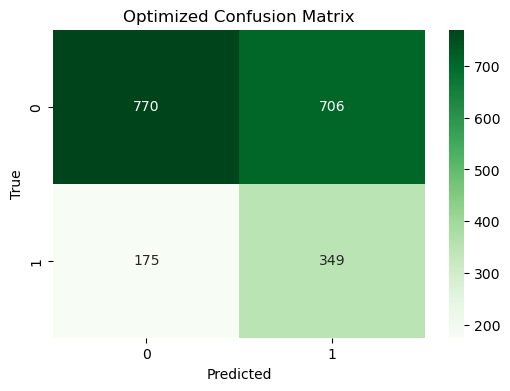


ROC Curve:


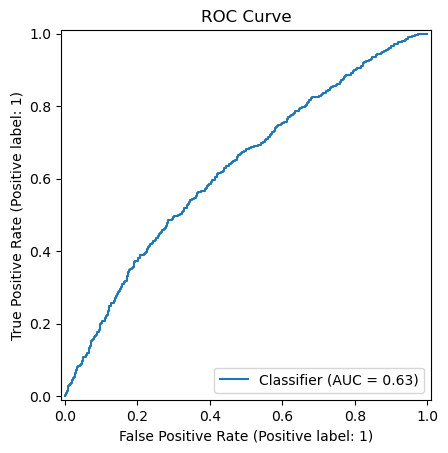


Precision-Recall Curve:


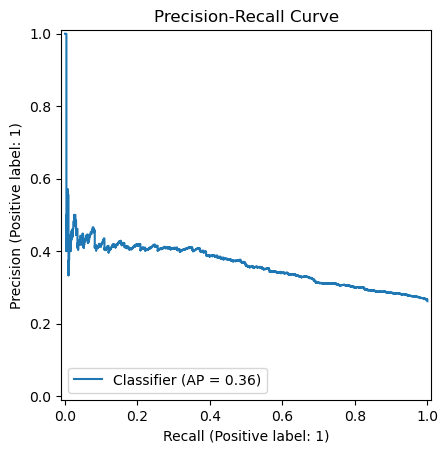

In [65]:
# ==================================
#  REPORTS FOR OPTIMIZED PERFORMANCE
# ==================================

print("\n" + "="*40)
print("Optimized Performance Reports (using best threshold)")
print("="*40)

# 1. Classification Report for Optimized Predictions
print("\nOptimized Classification Report:")
print(classification_report(y_test, y_pred_opt, digits=4))

# 2. Confusion Matrix for Optimized Predictions
print("\nOptimized Confusion Matrix:")
cm_opt = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Optimized Confusion Matrix')
plt.show()

# The ROC and Precision-Recall curves are based on probabilities, so they don't change
# with the threshold, but it's good practice to show them alongside the final chosen metrics.

# 3. ROC Curve
print("\nROC Curve:")
RocCurveDisplay.from_predictions(y_test, y_proba) # y_proba are the probabilities from the best model
plt.title('ROC Curve')
plt.show()

# 4. Precision-Recall Curve
print("\nPrecision-Recall Curve:")
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title('Precision-Recall Curve')
plt.show()